In [1]:
import os
import random
import time
from pathlib import Path
from tqdm import tqdm
import numpy as np
from PIL import Image
from datetime import datetime
import csv
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import torch.nn.functional as F

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from jpeg_aug import RandomJPEGCompression
from helper_functions import *

In [2]:
# Checking Device/confirming it works with CUDA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


In [3]:
# adjust as needed to main path where data is. Should be 'DS6050_Ai_Detection' folder
data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")

# train/validate on percent of data. 0.1 = 10%, 1.0 = 100%
train_percent = 0.1

# adjust as needed for training device
batch_size = 16

# workers seem to be bugged, 0 works best
num_workers = 0

learning_rate = 1e-4

# using jpeg compression augmentation during training?
jpeg_compression = True

# number of epochs
num_epochs = 5

model_name = 'resnet50_fft'

# additional name to add at end of model name for logging and pth file
save_model_name = "regular"

make_images = True

# fft helper for dataloading
if 'fft' in model_name:
    fft = True
else:
    fft = False

In [4]:
train_loader, val_loader, train_dataset, val_dataset, csv_name = main_data_loading(data_root, model_name, train_percent, 
                                                                                   batch_size, num_workers=num_workers, 
                                                                                   jpeg_compression=jpeg_compression)

Using model type: resnet50
Using FFT: True
Original class mapping: {'fake': 0, 'real': 1}
Using 10.0% of the data
Training on 11520 images, validating on 2834 images.
Saved dataset split CSV to: logs/dataset_split_20251206_173210.csv
Total records: 14354


In [5]:
confirm_labels(train_dataset, val_dataset)

Confirm correct labels
fake -> 1
real -> 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\010956.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\117162.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0033883.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\004497.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\059987.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\011806.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\012341.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\real\0016687.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\real\0023341.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\017221.png --> Label: 1


In [6]:
# MODEL SETUP (ResNet50 with FFT)

zero_init = True

model = models.resnet50(weights=True)
num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),   # hidden layer
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 2)           # final output
)

# updating model to handle FFT, swiching CNN to 6
old_conv = model.conv1
model.conv1 = nn.Conv2d(
    in_channels=6,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

# initialize the extra channels for CNN
with torch.no_grad():
    model.conv1.weight[:, :3] = old_conv.weight  # keep pretrained RGB filters
    if zero_init is True:
        model.conv1.weight[:, 3:] = torch.zeros_like(old_conv.weight[:, :3]) # zero init
    else:
        model.conv1.weight[:, 3:] = old_conv.weight.mean(dim=1, keepdim=True)  # duplicate as “gray”


model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # adding label smoothing for better generalization

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # adding L2 regularization

c:\Users\Jimmy\miniconda3\envs\id_ai\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


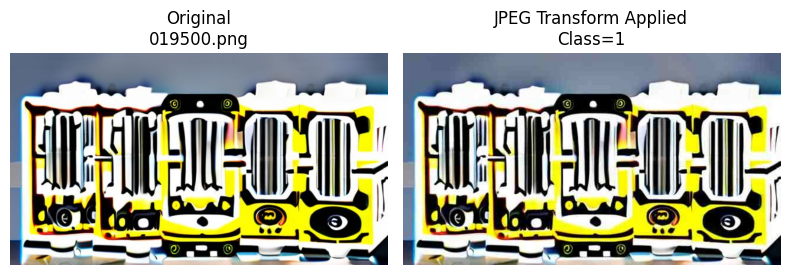

In [7]:
show_jpeg_transform_effect(val_dataset, index = 10, jpeg_q_range=(5, 60)) # range can go from 5 - 95

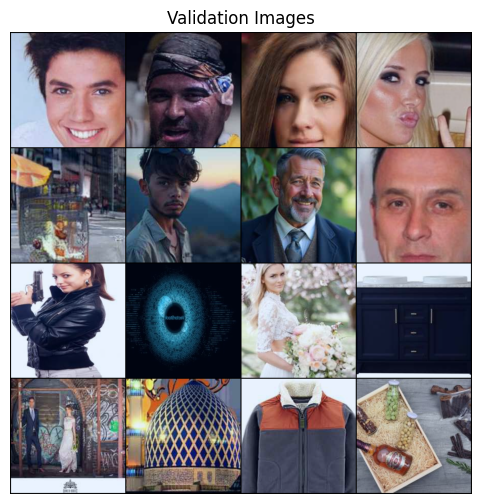

Fake: 019416.png
Fake: 032713.png
Fake: 007678.png
Fake: 015067.png
Fake: 035497.png
Fake: 028476.png
Fake: 030732.png
Fake: 002084.png
Real: 0001554.png
Real: 0020075.png
Real: 0025997.png
Real: 0015822.png
Real: 0006720.png
Real: 0008957.png
Real: 0024939.png
Real: 0017805.png


In [8]:
fixed_images, fixed_labels, grid_size = create_grid_of_val_images(val_dataset, grid_size=4, 
                                                                  fft=fft, device=device, keep=True)

Using device: cuda (NVIDIA GeForce RTX 4070 Ti)

- Epoch 1/5


Training: 100%|██████████| 720/720 [01:54<00:00,  6.27batch/s, Loss=0.4969, Train Acc=80.11%]


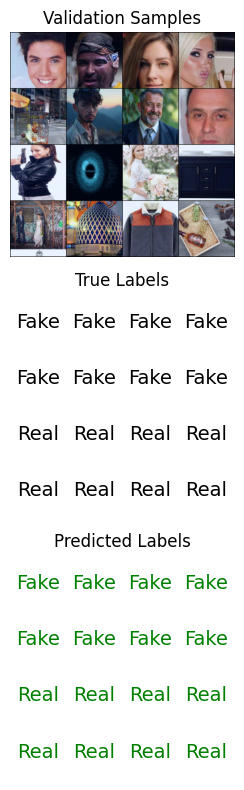

Epoch 1/5 Loss: 0.4969 | Train Acc: 80.11% | Val Acc: 83.38%
Precision: 0.8118 | Recall: 0.8726
F1 Score: 0.8411 | ROC-AUC: 0.9215%

- Epoch 2/5


Training:  55%|█████▍    | 393/720 [01:01<00:51,  6.41batch/s, Loss=0.2471, Train Acc=83.91%]


KeyboardInterrupt: 

In [9]:
h = train_model(model=model, train_loader=train_loader, val_loader=val_loader,
                criterion=criterion, optimizer=optimizer, num_epochs=num_epochs,
                batch_size=batch_size, device=device, fft=fft,model_name=model_name, csv_name_used=csv_name,
                model_save_name=save_model_name, make_images=make_images, fixed_images=fixed_images,
                fixed_labels=fixed_labels, grid_size=grid_size)